<a href="https://colab.research.google.com/github/KadenLu/Kaden-s-Individual-Project/blob/main/Kaden's_Attempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title generate data for clustering

import pandas as pd
import numpy as np
from google.colab import drive
import random

# 1. Mount Google Drive
drive.mount('/content/drive')

# Set the base directory path based on your folder name
base_path = '/content/drive/MyDrive/kaden_projects/'

print("Loading and filtering users...")
# 2. Load users and filter demographics
# We drop rows where key demographic/personal data is missing (NaN)
users = pd.read_csv(base_path + 'users_cleaned.csv')
demographic_cols = ['gender', 'location', 'birth_date']
cols_to_check = [c for c in demographic_cols if c in users.columns] # Failsafe in case of slight schema variations
users_valid = users.dropna(subset=cols_to_check)
valid_usernames = set(users_valid['username'])

print("Loading anime means...")
# 3. Load anime mean scores
# We only need the anime ID and the global mean score for that anime
anime = pd.read_csv(base_path + 'anime_cleaned.csv', usecols=['anime_id', 'score'])
anime = anime.rename(columns={'score': 'anime_mean_score'})

print("Loading, sampling, and filtering animelists... (This might take a moment)")

file_path = base_path + 'animelists_cleaned.csv'
sample_size = 5000000

print("Reading and sampling the CSV directly into memory...")
# 4. Read the CSV, top 5 million
animelists = pd.read_csv(
    file_path,
    usecols=['username', 'anime_id', 'my_score'], # Still a good idea to only keep needed columns
    nrows=sample_size
)

# Filter out invalid ratings (<= 0 or > 10)
animelists = animelists[(animelists['my_score'] > 0) & (animelists['my_score'] <= 10)]

# Filter out users with no demographic data
animelists = animelists[animelists['username'].isin(valid_usernames)]

# Filter out users who have rated less than 6 anime (within this sample)
user_counts = animelists['username'].value_counts()
users_with_enough_ratings = user_counts[user_counts >= 6].index
animelists = animelists[animelists['username'].isin(users_with_enough_ratings)]

print("Calculating metrics...")
# 5. Merge lists with anime global scores to calculate the difference
animelists = animelists.merge(anime, on='anime_id', how='inner')
animelists['score_diff'] = animelists['my_score'] - animelists['anime_mean_score']

# 6. Generate the final dataframe with personal variance and avg score difference
final_user_stats = animelists.groupby('username').agg(
    personal_variance=('my_score', 'var'),
    avg_score_diff=('score_diff', 'mean')
).reset_index()

print("\n--- Final DataFrame ---")
display(final_user_stats.head(10))

Mounted at /content/drive
Loading and filtering users...
Loading anime means...
Loading, sampling, and filtering animelists... (This might take a moment)
Reading and sampling the CSV directly into memory...
Calculating metrics...

--- Final DataFrame ---


,username,personal_variance,avg_score_diff
0,--FallenAngel--,0.953800,0.821432
1,-Ackerman,1.191734,-0.229811
2,-Alicia-San-,3.109397,-0.671935
3,-Anna-,3.263885,-0.278576
4,-Araragi-,0.923803,0.256151
5,-Arlequin-,2.352659,-1.366895
6,-Ayumi-,0.474798,1.365312
7,-Azazel-,3.277914,-0.413873
8,-Azure-,2.421539,-2.934568
9,-Balmung-,1.692010,-1.287918


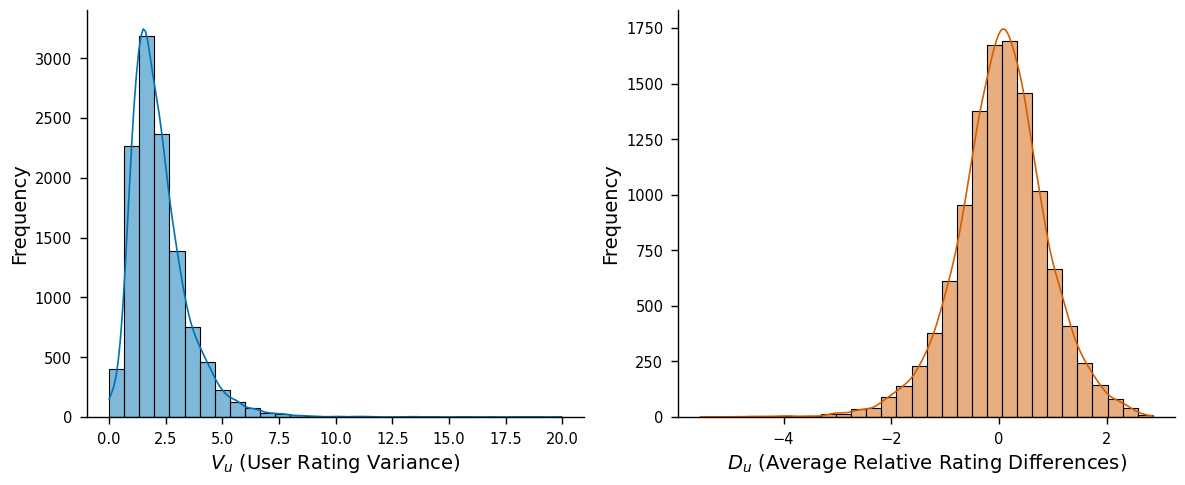

In [11]:
#@title user analysis histograms

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset
df = final_user_stats

# Set the style for a scientific publication
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.2)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: User Rating Variance (Vu)
# Color: #0072b2 (Blue from Okabe-Ito palette)
sns.histplot(df['personal_variance'], bins=30, kde=True, ax=axes[0], color='#0072b2')
axes[0].set_xlabel(r'$V_u$ (User Rating Variance)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)

# Plot 2: Average Relative Difference (Du)
# Color: #d55e00 (Vermillion from Okabe-Ito palette)
sns.histplot(df['avg_score_diff'], bins=30, kde=True, ax=axes[1], color='#d55e00')
axes[1].set_xlabel(r'$D_u$ (Average Relative Rating Differences)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# Remove borders
sns.despine()

# Adjust layout to prevent label truncation
plt.tight_layout()

# Save the figure for your manuscript
plt.savefig('figure_1_histograms.png', dpi=300)
plt.show()

In [ ]:
final_user_stats.shape

(11335, 3)

<Axes: >

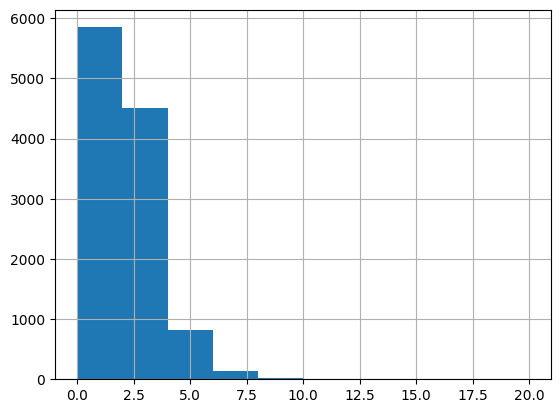

In [ ]:
final_user_stats.personal_variance.hist()

<Axes: >

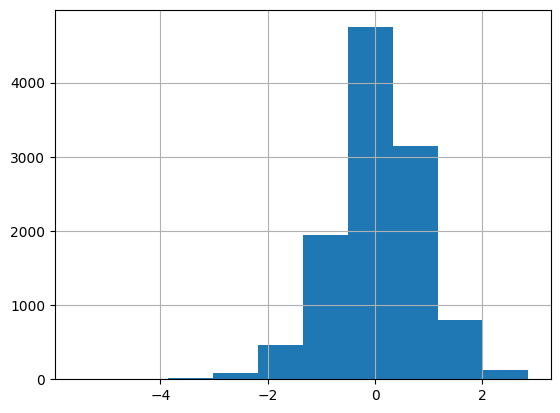

In [ ]:
final_user_stats.avg_score_diff.hist()

In [ ]:
final_user_stats.avg_score_diff.mean()

np.float64(0.051132099038930005)

Preparing data for clustering...
Running K-Means and generating plots with centroids...

--- Centroid Coordinates for k=2 ---
Cluster 0: Avg Score Diff = 0.3965, Personal Variance = 1.6562
Cluster 1: Avg Score Diff = -0.7929, Personal Variance = 3.6121

--- Centroid Coordinates for k=3 ---
Cluster 0: Avg Score Diff = -0.1609, Personal Variance = 2.0903
Cluster 1: Avg Score Diff = -1.0304, Personal Variance = 4.3765
Cluster 2: Avg Score Diff = 0.9142, Personal Variance = 1.4000

--- Centroid Coordinates for k=4 ---
Cluster 0: Avg Score Diff = 0.0574, Personal Variance = 1.6841
Cluster 1: Avg Score Diff = -0.5320, Personal Variance = 3.0083
Cluster 2: Avg Score Diff = 1.1201, Personal Variance = 1.4000
Cluster 3: Avg Score Diff = -1.2602, Personal Variance = 5.3042

--- Centroid Coordinates for k=5 ---
Cluster 0: Avg Score Diff = -0.0205, Personal Variance = 1.5550
Cluster 1: Avg Score Diff = -1.0182, Personal Variance = 2.9878
Cluster 2: Avg Score Diff = 1.1188, Personal Variance = 1.27

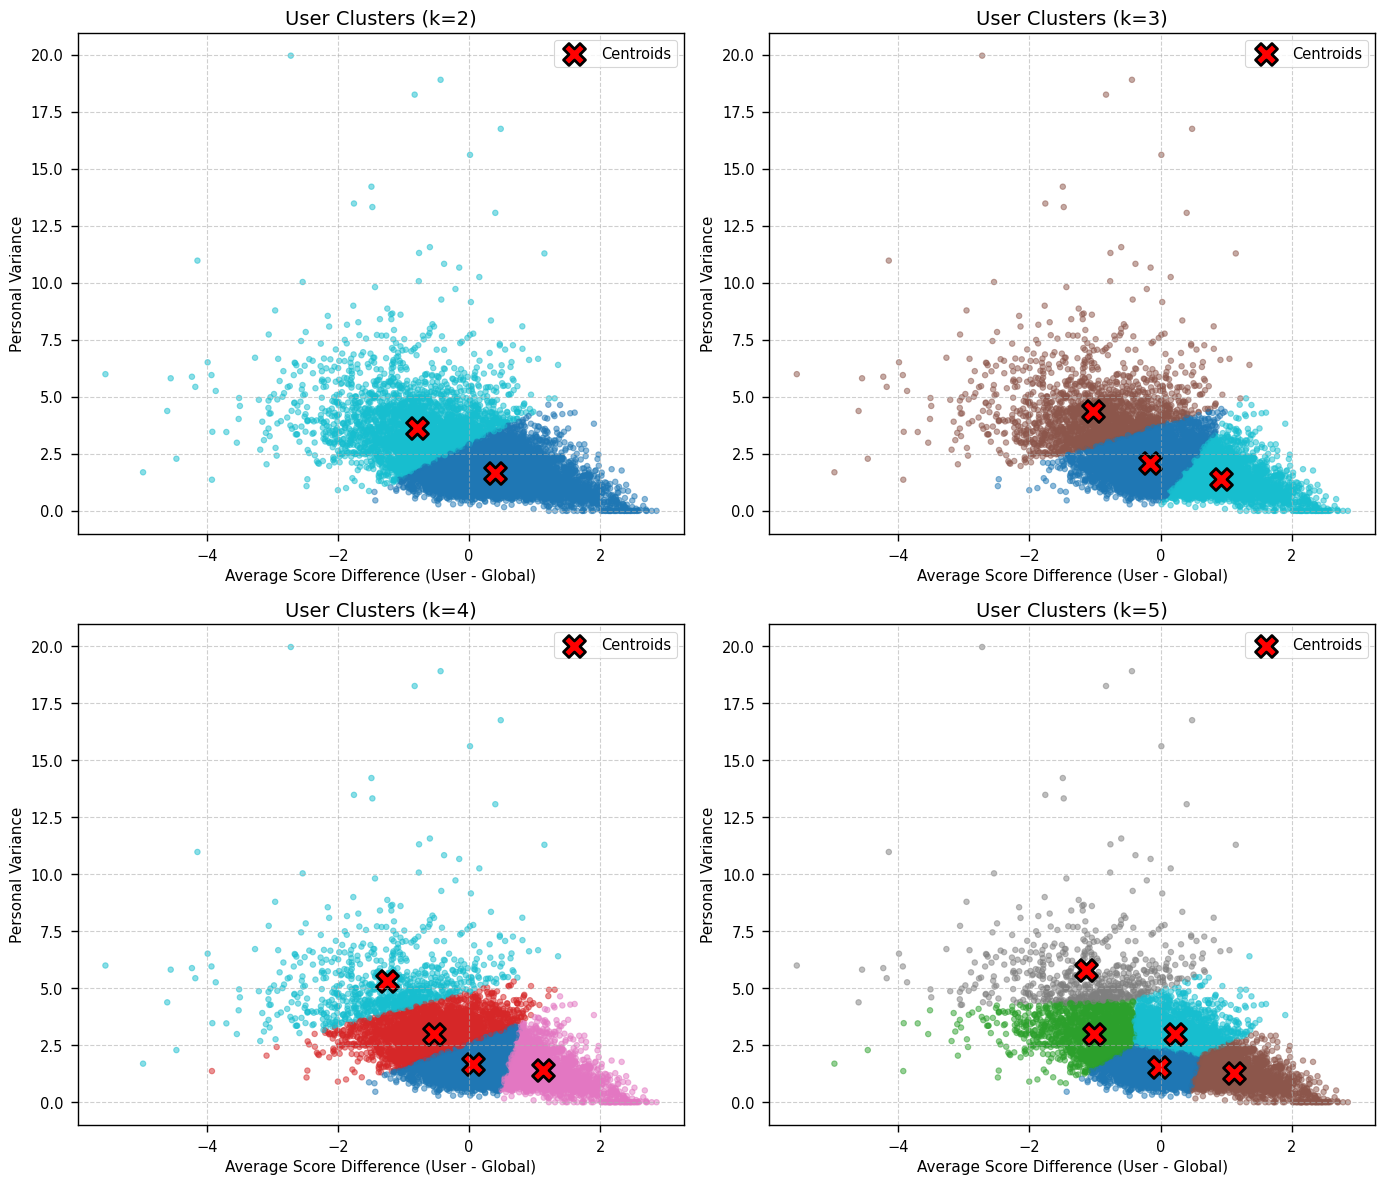

In [5]:
#@title visualize clusters k=2-5

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Preparing data for clustering...")
# 1. Isolate the features we want to use
cluster_df = final_user_stats[['personal_variance', 'avg_score_diff']].dropna()

# 2. Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

print("Running K-Means and generating plots with centroids...")
# 3. Set up a 2x2 grid of subplots for our visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

k_values = [2, 3, 4, 5]

for i, k in enumerate(k_values):
    # Initialize and fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_features)

    # --- NEW: Extract and un-scale the centroids ---
    # Get centroids in the scaled space
    scaled_centroids = kmeans.cluster_centers_
    # Revert centroids back to original units (Variance and Score Diff)
    original_centroids = scaler.inverse_transform(scaled_centroids)

    # --- ADDED: Print the un-scaled centroid coordinates ---
    print(f"\n--- Centroid Coordinates for k={k} ---")
    for cluster_idx, centroid in enumerate(original_centroids):
        # centroid[0] is personal_variance, centroid[1] is avg_score_diff
        variance = centroid[0]
        score_diff = centroid[1]
        print(f"Cluster {cluster_idx}: Avg Score Diff = {score_diff:.4f}, Personal Variance = {variance:.4f}")

    # Plot on the corresponding subplot
    ax = axes[i]

    # Plot the user data points
    scatter = ax.scatter(
        cluster_df['avg_score_diff'],
        cluster_df['personal_variance'],
        c=cluster_labels,
        cmap='tab10',
        alpha=0.5,
        s=15
    )

    # --- NEW: Plot the centroids ---
    # original_centroids[:, 1] is avg_score_diff (X-axis)
    # original_centroids[:, 0] is personal_variance (Y-axis)
    ax.scatter(
        original_centroids[:, 1],
        original_centroids[:, 0],
        c='red',             # Bright color to stand out
        marker='X',          # Distinct shape
        s=250,               # Large size
        edgecolors='black',  # Black border for contrast
        linewidths=2,
        label='Centroids'
    )

    ax.set_title(f'User Clusters (k={k})', fontsize=14)
    ax.set_xlabel('Average Score Difference (User - Global)', fontsize=11)
    ax.set_ylabel('Personal Variance', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add a legend just to label the centroid
    ax.legend()

plt.tight_layout()
plt.show()

Preparing and scaling data...
Calculating WCSS and Silhouette Scores for k=2 through k=10...
Generating evaluation plots...


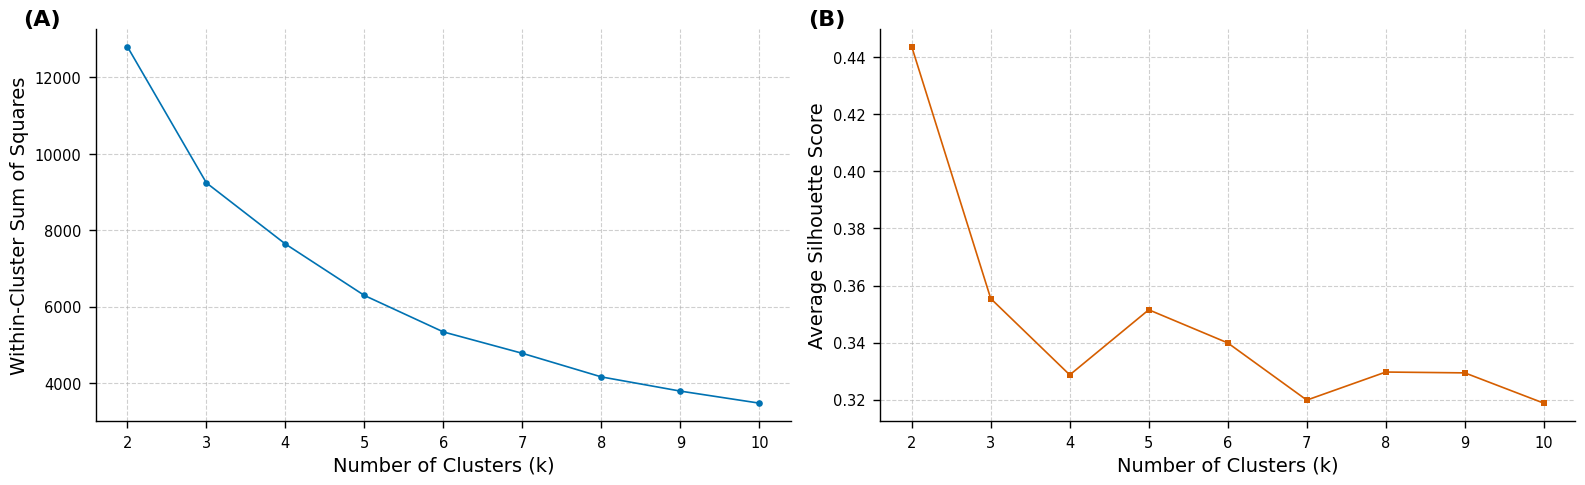

In [12]:
#@title determine number of clusters: k=3 is a good tradeoff

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Preparing and scaling data...")
# Ensure data is prepared and scaled
cluster_df = final_user_stats[['personal_variance', 'avg_score_diff']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

print("Calculating WCSS and Silhouette Scores for k=2 through k=10...")
# Define the range of k we want to test
k_range = range(2, 11)

wcss = []
silhouette_scores = []

for k in k_range:
    # Fit the model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_features)

    # 1. Append WCSS (Inertia)
    wcss.append(kmeans.inertia_)

    # 2. Append Silhouette Score
    score = silhouette_score(scaled_features, cluster_labels, random_state=42)
    silhouette_scores.append(score)

print("Generating evaluation plots...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Method (WCSS)
# Color: #0072b2 (Blue from Okabe-Ito palette)
ax1.plot(k_range, wcss, marker='o', linestyle='-', color='#0072b2')
ax1.set_xlabel('Number of Clusters (k)', fontsize=14)
ax1.set_ylabel('Within-Cluster Sum of Squares', fontsize=14)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.text(-0.05, 1.05, '(A)', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Plot 2: Silhouette Score
# Color: #d55e00 (Vermillion from Okabe-Ito palette)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='#d55e00')
ax2.set_xlabel('Number of Clusters (k)', fontsize=14)
ax2.set_ylabel('Average Silhouette Score', fontsize=14)
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.text(-0.05, 1.05, '(B)', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Remove borders
sns.despine()

plt.tight_layout()
# Save the figure
plt.savefig('cluster_evaluation.png', dpi=300)
plt.show()

In [8]:
#@title prepare data for training by populating user features

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("1. Preparing and scaling the data...")
# Isolate the features and drop any missing values
cluster_df = final_user_stats[['username', 'personal_variance', 'avg_score_diff']].dropna()
features = cluster_df[['personal_variance', 'avg_score_diff']]

# Scale the data (crucial for K-Means distance calculations)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("2. Running K-Means (k=3)...")
# Fit the model and get the raw cluster labels (0, 1, or 2)
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_df['cluster_num'] = kmeans.fit_predict(scaled_features)

print("3. Extracting Centroids to classify groups...")
# Extract the exact mathematical center (centroid) of each cluster
# We use inverse_transform to convert them from Z-scores back to normal numbers
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Create a mini dataframe just for the centroids to make them easy to sort
centroids_df = pd.DataFrame(centroids, columns=['centroid_variance', 'centroid_score_diff'])
centroids_df['cluster_num'] = centroids_df.index # Index 0, 1, 2 matches the cluster labels

# Sort the centroids from lowest score difference to highest
centroids_sorted = centroids_df.sort_values(by='centroid_score_diff')

# 4. Map the sorted centroids to our human labels
# iloc[0] is the lowest score diff, iloc[2] is the highest
label_mapping = {
    centroids_sorted.iloc[0]['cluster_num']: 'Critical',
    centroids_sorted.iloc[1]['cluster_num']: 'Average',
    centroids_sorted.iloc[2]['cluster_num']: 'Generous'
}

print(f"Centroid Mapping Logic: \n{label_mapping}\n")

# Apply the mapped labels back to our users
cluster_df['user_persona'] = cluster_df['cluster_num'].map(label_mapping)

print("4. Merging with full user profile data...")
# Load the original users dataset
# (Ensure base_path is defined, e.g., base_path = '/content/drive/MyDrive/kaden_projects/')
users_full = pd.read_csv(base_path + 'users_cleaned.csv')

# Inner merge to combine the persona classifications with the demographic data
classified_users_df = users_full.merge(
    cluster_df[['username', 'user_persona', 'personal_variance', 'avg_score_diff']],
    on='username',
    how='inner'
)

print("\n--- Final Classified DataFrame ---")
display(classified_users_df.head(10))

1. Preparing and scaling the data...
2. Running K-Means (k=3)...
3. Extracting Centroids to classify groups...
Centroid Mapping Logic: 
{np.float64(1.0): 'Critical', np.float64(0.0): 'Average', np.float64(2.0): 'Generous'}

4. Merging with full user profile data...

--- Final Classified DataFrame ---


,username,user_id,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,access_rank,join_date,last_online,stats_mean_score,stats_rewatched,stats_episodes,user_persona,personal_variance,avg_score_diff
0,karthiga,2255153,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,NaN,2013-03-03 00:00:00,2014-02-04 01:32:00,7.43,0.0,3391,Average,1.519594,-0.509057
1,Damonashu,37326,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,NaN,2008-02-13 00:00:00,2017-07-10 06:52:54,6.15,6.0,4903,Critical,4.234817,-1.578196
2,bskai,228342,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,NaN,2009-08-31 00:00:00,2014-05-12 16:35:00,8.27,1.0,9701,Generous,1.530924,0.954353
3,Slimak,61677,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,NaN,2008-05-18 00:00:00,2018-05-01 12:05:21,7.77,2.0,7447,Average,1.249263,0.193722
4,MistButterfly,2485327,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,NaN,2013-04-25 00:00:00,2018-05-17 13:31:00,5.49,0.0,39703,Average,2.000800,-1.471106
5,kioniel,144049,11,433,5,2,0,164.352778,Male,home,1988-01-16 00:00:00,NaN,2009-01-29 00:00:00,2017-05-31 05:57:00,7.84,0.0,9850,Average,3.089510,0.358412
6,Xinil,1,4,230,8,89,60,109.438194,Male,California,1985-03-04 00:00:00,NaN,2004-11-05 00:00:00,2018-05-14 18:02:55,7.37,58.0,6536,Average,1.667074,-0.194031
7,ihasabucket,18867,6,146,15,25,15,62.339583,Male,"San Jose, CA",1984-09-08 00:00:00,NaN,2007-10-26 00:00:00,2015-06-28 01:17:00,7.84,0.0,3745,Average,2.495042,0.011329
8,xTheFallenx,340873,22,655,2,3,212,130.503472,Male,somewhere really hot,1993-05-29 00:00:00,NaN,2010-06-13 00:00:00,2018-05-08 04:27:20,8.02,0.0,8507,Generous,1.736005,0.643673
9,L-LawlietDN,14658,5,0,0,1,0,1.778472,Male,Guess,1995-05-29 00:00:00,NaN,2007-09-23 00:00:00,2008-04-24 16:01:00,8.33,7.0,111,Critical,13.066667,0.398333


In [ ]:
cluster_df

,username,personal_variance,avg_score_diff,cluster_num,user_persona
0,--FallenAngel--,0.953800,0.821432,2,Generous
1,-Ackerman,1.191734,-0.229811,0,Average
2,-Alicia-San-,3.109397,-0.671935,0,Average
3,-Anna-,3.263885,-0.278576,0,Average
4,-Araragi-,0.923803,0.256151,2,Generous
...,...,...,...,...,...
11330,zvenalot,2.045000,0.371800,0,Average
11331,zwil,2.420479,0.307260,0,Average
11332,zwr,1.344538,1.498619,2,Generous
11333,zync,3.493419,-1.939826,1,Critical


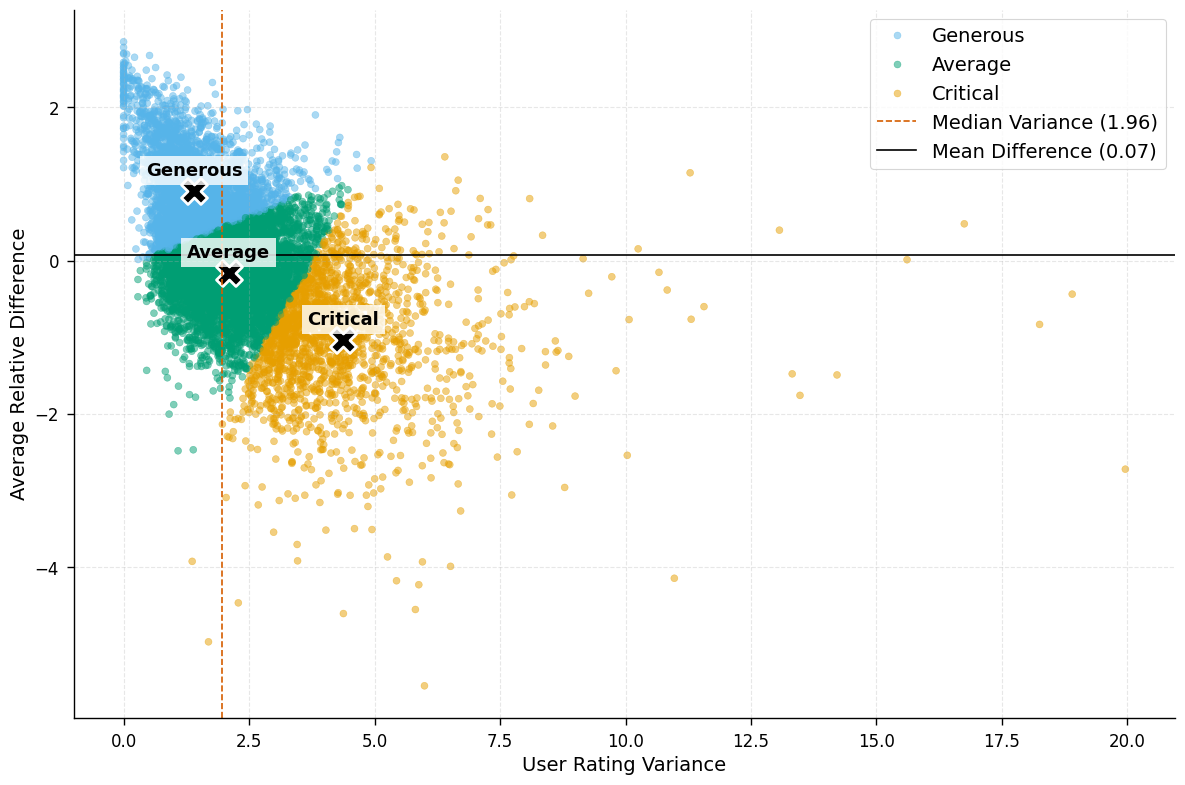

Total Users: 11335
cluster_name
Average     5881
Generous    3686
Critical    1768
Name: count, dtype: int64


In [10]:
#@title visualize clusters (Updated for k=3 Centroids)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare data mapping (Keeping original cluster names)
# cluster 1 -> Critical
# cluster 0 -> Average
# cluster 2 -> Generous

cluster_to_name = {
    1: "Critical",
    0: "Average",
    2: "Generous"
}

# Map the names to our dataframe
cluster_df['cluster_name'] = cluster_df['cluster_num'].map(cluster_to_name)

# 2. Get the 3 Centroids from the cluster_df features
centroids_plot = cluster_df.groupby('cluster_num').agg({
    'personal_variance': 'mean',
    'avg_score_diff': 'mean'
}).reset_index()

# --- VISUALIZATION ---
plt.figure(figsize=(12, 8))
# Using Color-blind friendly palette (Okabe-Ito inspired)
palette = {
    "Critical": "#E69F00",    # Orange
    "Average": "#009E73",     # Bluish Green
    "Generous": "#56B4E9"    # Sky Blue
}

sns.scatterplot(
    data=cluster_df,
    x='personal_variance', y='avg_score_diff',
    hue='cluster_name', palette=palette,
    alpha=0.5, s=25, edgecolor=None
)

# Plot Centroids with labels
for _, row in centroids_plot.iterrows():
    cluster_id = int(row['cluster_num'])
    name = cluster_to_name.get(cluster_id, f"Cluster {cluster_id}")
    plt.scatter(row['personal_variance'], row['avg_score_diff'],
                marker='X', s=350, color='black', edgecolor='white', linewidth=2)
    plt.text(row['personal_variance'], row['avg_score_diff'] + 0.2,
             name, weight='bold', size=13, ha='center',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Add the Quadrant Lines
median_var = cluster_df['personal_variance'].median()
median_diff = cluster_df['avg_score_diff'].median()
plt.axvline(x=median_var, color='#D55E00', linestyle='--', label=f'Median Variance ({median_var:.2f})')
plt.axhline(y=median_diff, color='black', linestyle='-', label=f'Mean Difference ({median_diff:.2f})')

# Format labels
plt.xlabel('User Rating Variance', fontsize=14)
plt.ylabel('Average Relative Difference', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

# Remove borders
sns.despine()

plt.tight_layout()
# Save the figure
plt.savefig('cluster_visualization_accessible.png', dpi=300)
plt.show()

# Final Verification
print("Total Users:", len(cluster_df))
print(cluster_df['cluster_name'].value_counts())

In [ ]:
list_df = classified_users_df.drop(columns=['username', 'user_id', 'access_rank', 'stats_mean_score', 'personal_variance', 'avg_score_diff'])
display(list_df.head(10))

,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,join_date,last_online,stats_rewatched,stats_episodes,user_persona
0,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,2013-03-03 00:00:00,2014-02-04 01:32:00,0.0,3391,Average
1,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,2008-02-13 00:00:00,2017-07-10 06:52:54,6.0,4903,Critical
2,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,2009-08-31 00:00:00,2014-05-12 16:35:00,1.0,9701,Generous
3,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,2008-05-18 00:00:00,2018-05-01 12:05:21,2.0,7447,Average
4,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,2013-04-25 00:00:00,2018-05-17 13:31:00,0.0,39703,Average
5,11,433,5,2,0,164.352778,Male,home,1988-01-16 00:00:00,2009-01-29 00:00:00,2017-05-31 05:57:00,0.0,9850,Average
6,4,230,8,89,60,109.438194,Male,California,1985-03-04 00:00:00,2004-11-05 00:00:00,2018-05-14 18:02:55,58.0,6536,Average
7,6,146,15,25,15,62.339583,Male,"San Jose, CA",1984-09-08 00:00:00,2007-10-26 00:00:00,2015-06-28 01:17:00,0.0,3745,Average
8,22,655,2,3,212,130.503472,Male,somewhere really hot,1993-05-29 00:00:00,2010-06-13 00:00:00,2018-05-08 04:27:20,0.0,8507,Generous
9,5,0,0,1,0,1.778472,Male,Guess,1995-05-29 00:00:00,2007-09-23 00:00:00,2008-04-24 16:01:00,7.0,111,Critical


In [ ]:
list_df.location.unique().shape

(6227,)

In [ ]:

display(list_df.head(10))

,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,location,birth_date,join_date,last_online,stats_rewatched,stats_episodes,user_persona
0,3,49,1,0,0,55.091667,Female,"Chennai, India",1990-04-29 00:00:00,2013-03-03 00:00:00,2014-02-04 01:32:00,0.0,3391,Average
1,45,195,27,25,59,82.574306,Male,"Detroit,Michigan",1991-08-01 00:00:00,2008-02-13 00:00:00,2017-07-10 06:52:54,6.0,4903,Critical
2,25,414,2,5,11,159.483333,Male,"Nayarit, Mexico",1990-12-14 00:00:00,2009-08-31 00:00:00,2014-05-12 16:35:00,1.0,9701,Generous
3,79,224,0,3,84,124.731944,Male,Poland,1988-02-21 00:00:00,2008-05-18 00:00:00,2018-05-01 12:05:21,2.0,7447,Average
4,66,3923,115,0,368,608.234514,Female,~ Hungary ~,1992-01-16 00:00:00,2013-04-25 00:00:00,2018-05-17 13:31:00,0.0,39703,Average
5,11,433,5,2,0,164.352778,Male,home,1988-01-16 00:00:00,2009-01-29 00:00:00,2017-05-31 05:57:00,0.0,9850,Average
6,4,230,8,89,60,109.438194,Male,California,1985-03-04 00:00:00,2004-11-05 00:00:00,2018-05-14 18:02:55,58.0,6536,Average
7,6,146,15,25,15,62.339583,Male,"San Jose, CA",1984-09-08 00:00:00,2007-10-26 00:00:00,2015-06-28 01:17:00,0.0,3745,Average
8,22,655,2,3,212,130.503472,Male,somewhere really hot,1993-05-29 00:00:00,2010-06-13 00:00:00,2018-05-08 04:27:20,0.0,8507,Generous
9,5,0,0,1,0,1.778472,Male,Guess,1995-05-29 00:00:00,2007-09-23 00:00:00,2008-04-24 16:01:00,7.0,111,Critical


Engineering datetime features into months...
Preparing data for modeling...
Running 10-Fold Cross-Validation (This might take a moment)...

 10-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy:   0.4416 ± 0.0221
Mean Macro F1:   0.4181 ± 0.0212

Generating Cross-Validated Confusion Matrix...


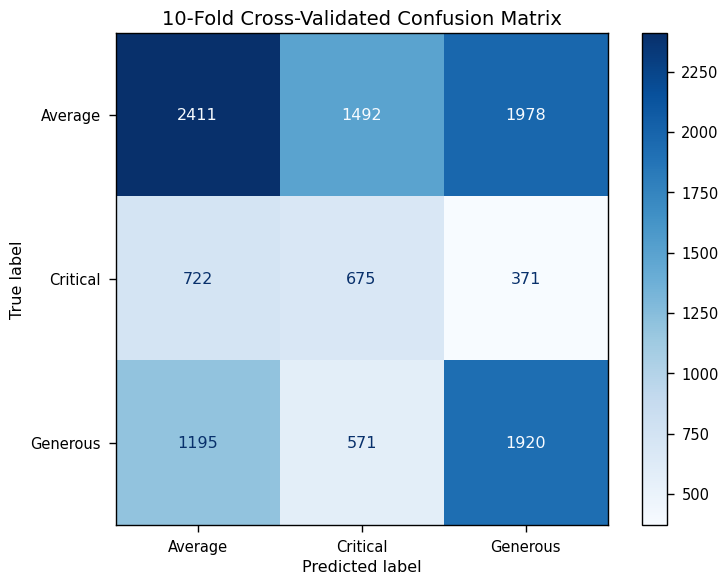

In [18]:
#@title classification using decision tree

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Apply your column drops to create list_df
cols_to_drop = [
    'username', 'user_id', 'access_rank', 'stats_mean_score',
    'personal_variance', 'avg_score_diff', 'location'
]
list_df = classified_users_df.drop(columns=cols_to_drop, errors='ignore')

print("Engineering datetime features into months...")

# Define the target date: Jan 1st, 2026
target_date = pd.to_datetime('2026-01-01')

# Convert date columns to datetime objects (invalid dates become NaNs)
date_cols = ['birth_date', 'join_date', 'last_online']
for col in date_cols:
    if col in list_df.columns:
        list_df[col] = pd.to_datetime(list_df[col], errors='coerce')

# 2. Calculate months from each date to Jan 1, 2026
if 'birth_date' in list_df.columns:
    list_df['months_lived'] = (target_date.year - list_df['birth_date'].dt.year) * 12 + (target_date.month - list_df['birth_date'].dt.month)

if 'join_date' in list_df.columns:
    list_df['months_since_join'] = (target_date.year - list_df['join_date'].dt.year) * 12 + (target_date.month - list_df['join_date'].dt.month)

if 'last_online' in list_df.columns:
    list_df['months_since_last_online'] = (target_date.year - list_df['last_online'].dt.year) * 12 + (target_date.month - list_df['last_online'].dt.month)

# 3. Create the 2 new relative interaction features
if 'join_date' in list_df.columns and 'birth_date' in list_df.columns:
    list_df['age_at_join_months'] = (list_df['join_date'].dt.year - list_df['birth_date'].dt.year) * 12 + (list_df['join_date'].dt.month - list_df['birth_date'].dt.month)

if 'last_online' in list_df.columns and 'join_date' in list_df.columns:
    list_df['active_duration_months'] = (list_df['last_online'].dt.year - list_df['join_date'].dt.year) * 12 + (list_df['last_online'].dt.month - list_df['join_date'].dt.month)

# 4. Handle NaNs with the median and drop original datetime strings
engineered_cols = [
    'months_lived', 'months_since_join', 'months_since_last_online',
    'age_at_join_months', 'active_duration_months'
]

for col in engineered_cols:
    if col in list_df.columns:
        list_df[col] = list_df[col].fillna(list_df[col].median())

# Drop the original string/datetime columns
list_df = list_df.drop(columns=[c for c in date_cols if c in list_df.columns])

print("Preparing data for modeling...")
# 5. Drop rows where the target label is missing
list_df = list_df.dropna(subset=['user_persona'])

# 6. Separate features (X) and label (y)
X = list_df.drop(columns=['user_persona'])
y = list_df['user_persona']

# 7. Automatically identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Set up the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create the Pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42))
])

print("Running 10-Fold Cross-Validation (This might take a moment)...")
# 8. Run standard Cross-Validation for metrics
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    clf_pipeline, X, y, cv=10,
    scoring=scoring_metrics, return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*40)
print(" 10-FOLD CROSS-VALIDATION RESULTS")
print("="*40)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*40)

print("\nGenerating Cross-Validated Confusion Matrix...")
# 9. Get cross-validated predictions for the confusion matrix
y_pred = cross_val_predict(clf_pipeline, X, y, cv=10)

# 10. Generate and plot the matrix
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))

# Make the plot a bit larger for readability
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') # 'd' formats as standard integers

plt.title('10-Fold Cross-Validated Confusion Matrix', fontsize=14)
plt.grid(False) # Turn off the background grid so it doesn't overlap the matrix
plt.tight_layout()
plt.show()

In [ ]:
#@title output more eval metrics for decisoin tree

from sklearn.metrics import classification_report

print("\n" + "="*60)
print(" PER-CLASS METRICS (FROM CONFUSION MATRIX ROWS)")
print("="*60)

labels = np.unique(y)

# Print a custom, easy-to-read table calculating metrics row-by-row
print(f"{'Persona (Row)':<15} | {'Row Accuracy (Recall)':<25} | {'F1 Score'}")
print("-" * 60)

for i, label in enumerate(labels):
    # True Positives: The correct guesses on the diagonal
    TP = cm[i, i]

    # False Negatives: The rest of the row (Actuals that were guessed wrong)
    FN = cm[i, :].sum() - TP

    # False Positives: The rest of the column (Wrong guesses that landed here)
    FP = cm[:, i].sum() - TP

    # Row Accuracy (Recall): How many of the actuals did we find?
    row_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precision: How many of our guesses for this class were right?
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # F1 Score: The harmonic mean of Recall and Precision
    if (precision + row_accuracy) > 0:
        f1 = 2 * (precision * row_accuracy) / (precision + row_accuracy)
    else:
        f1 = 0

    print(f"{label:<15} | {row_accuracy:<25.4f} | {f1:.4f}")

print("\n\n" + "-"*60)
print(" SCIKIT-LEARN CLASSIFICATION REPORT")
print("-" * 60)
# Scikit-Learn's built-in way to show the exact same information
# Note: In this report, 'recall' is your row accuracy.
report = classification_report(y, y_pred, target_names=labels)
print(report)


 PER-CLASS METRICS (FROM CONFUSION MATRIX ROWS)
Persona (Row)   | Row Accuracy (Recall)     | F1 Score
------------------------------------------------------------
Average         | 0.4100                    | 0.4723
Critical        | 0.3818                    | 0.2996
Generous        | 0.5209                    | 0.4827


------------------------------------------------------------
 SCIKIT-LEARN CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

     Average       0.56      0.41      0.47      5881
    Critical       0.25      0.38      0.30      1768
    Generous       0.45      0.52      0.48      3686

    accuracy                           0.44     11335
   macro avg       0.42      0.44      0.42     11335
weighted avg       0.47      0.44      0.45     11335



Engineering datetime features into months...
Preparing data for modeling...
Running 10-Fold Cross-Validation (This might take a moment)...

 10-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy:   0.4399 ± 0.0223
Mean Macro F1:   0.4166 ± 0.0219

Generating Cross-Validated Confusion Matrix...


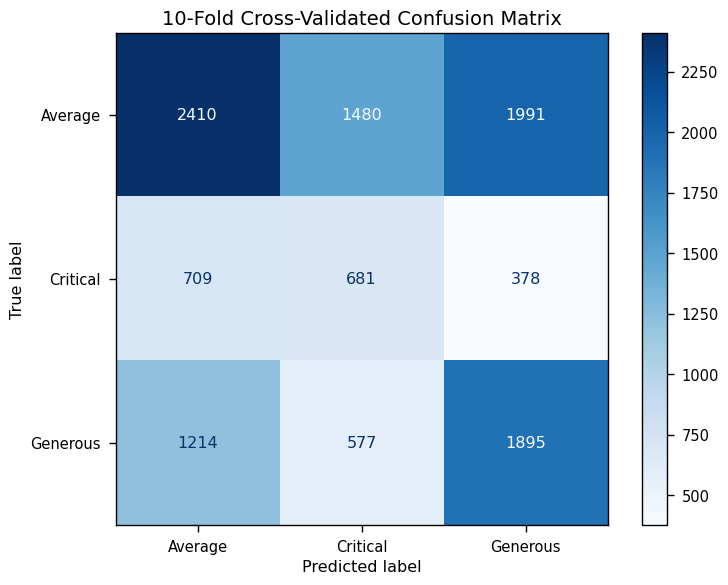

In [16]:
#@title classification using decision tree with behavioral only

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Apply your column drops to create list_df
cols_to_drop = [
    'username', 'user_id', 'access_rank', 'stats_mean_score',
    'personal_variance', 'avg_score_diff', 'location', 'gender', 'months_lived','age_at_join_months'
]
list_df = classified_users_df.drop(columns=cols_to_drop, errors='ignore')

print("Engineering datetime features into months...")

# Define the target date: Jan 1st, 2026
target_date = pd.to_datetime('2026-01-01')

# Convert date columns to datetime objects (invalid dates become NaNs)
date_cols = ['birth_date', 'join_date', 'last_online']
for col in date_cols:
    if col in list_df.columns:
        list_df[col] = pd.to_datetime(list_df[col], errors='coerce')

# 2. Calculate months from each date to Jan 1, 2026
if 'birth_date' in list_df.columns:
    list_df['months_lived'] = (target_date.year - list_df['birth_date'].dt.year) * 12 + (target_date.month - list_df['birth_date'].dt.month)

if 'join_date' in list_df.columns:
    list_df['months_since_join'] = (target_date.year - list_df['join_date'].dt.year) * 12 + (target_date.month - list_df['join_date'].dt.month)

if 'last_online' in list_df.columns:
    list_df['months_since_last_online'] = (target_date.year - list_df['last_online'].dt.year) * 12 + (target_date.month - list_df['last_online'].dt.month)

# 3. Create the 2 new relative interaction features
if 'join_date' in list_df.columns and 'birth_date' in list_df.columns:
    list_df['age_at_join_months'] = (list_df['join_date'].dt.year - list_df['birth_date'].dt.year) * 12 + (list_df['join_date'].dt.month - list_df['birth_date'].dt.month)

if 'last_online' in list_df.columns and 'join_date' in list_df.columns:
    list_df['active_duration_months'] = (list_df['last_online'].dt.year - list_df['join_date'].dt.year) * 12 + (list_df['last_online'].dt.month - list_df['join_date'].dt.month)

# 4. Handle NaNs with the median and drop original datetime strings
engineered_cols = [
    'months_lived', 'months_since_join', 'months_since_last_online',
    'age_at_join_months', 'active_duration_months'
]

for col in engineered_cols:
    if col in list_df.columns:
        list_df[col] = list_df[col].fillna(list_df[col].median())

# Drop the original string/datetime columns
list_df = list_df.drop(columns=[c for c in date_cols if c in list_df.columns])

print("Preparing data for modeling...")
# 5. Drop rows where the target label is missing
list_df = list_df.dropna(subset=['user_persona'])

# 6. Separate features (X) and label (y)
X = list_df.drop(columns=['user_persona'])
y = list_df['user_persona']

# 7. Automatically identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Set up the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create the Pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42))
])

print("Running 10-Fold Cross-Validation (This might take a moment)...")
# 8. Run standard Cross-Validation for metrics
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    clf_pipeline, X, y, cv=10,
    scoring=scoring_metrics, return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*40)
print(" 10-FOLD CROSS-VALIDATION RESULTS")
print("="*40)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*40)

print("\nGenerating Cross-Validated Confusion Matrix...")
# 9. Get cross-validated predictions for the confusion matrix
y_pred = cross_val_predict(clf_pipeline, X, y, cv=10)

# 10. Generate and plot the matrix
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))

# Make the plot a bit larger for readability
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d') # 'd' formats as standard integers

plt.title('10-Fold Cross-Validated Confusion Matrix', fontsize=14)
plt.grid(False) # Turn off the background grid so it doesn't overlap the matrix
plt.tight_layout()
plt.show()

In [ ]:
#@title Test random forest

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

# 1. Separate features (X) and label (y) from your already-engineered list_df
# (Assuming list_df is already prepared with the engineered month columns from the last step)
X = list_df.drop(columns=['user_persona'])
y = list_df['user_persona']

# 2. Automatically identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Set up the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 4. Create the Random Forest Pipeline
# n_estimators=200 means 200 trees. n_jobs=-1 uses all CPU cores to run faster.
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=12, class_weight='balanced',n_estimators=200, random_state=42, n_jobs=-1))
])

print("Running 10-Fold Cross-Validation for Random Forest (This will take a moment!)...")

# 5. Run standard Cross-Validation for global metrics
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    rf_pipeline, X, y, cv=10,
    scoring=scoring_metrics, return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*45)
print(" GLOBAL 10-FOLD CV RESULTS (RANDOM FOREST)")
print("="*45)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*45)

print("\nGenerating Cross-Validated Predictions for Per-Class Metrics...")
# 6. Get cross-validated predictions to calculate the row-by-row metrics
y_pred = cross_val_predict(rf_pipeline, X, y, cv=10, n_jobs=-1)
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
labels = np.unique(y)

print("\n" + "="*65)
print(" PER-CLASS METRICS (ROW BREAKDOWN)")
print("="*65)
print(f"{'Persona':<15} | {'Row Accuracy (Recall)':<25} | {'F1 Score'}")
print("-" * 65)

# 7. Calculate and print metrics for each specific row in the confusion matrix
for i, label in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP

    # Row Accuracy (Recall)
    row_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precision (Needed for F1)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # Per-class F1
    if (precision + row_accuracy) > 0:
        f1 = 2 * (precision * row_accuracy) / (precision + row_accuracy)
    else:
        f1 = 0

    print(f"{label:<15} | {row_accuracy:<25.4f} | {f1:.4f}")
print("="*65)

Running 10-Fold Cross-Validation for Random Forest (This will take a moment!)...

 GLOBAL 10-FOLD CV RESULTS (RANDOM FOREST)
Mean Accuracy:   0.5429 ± 0.0125
Mean Macro F1:   0.4722 ± 0.0179

Generating Cross-Validated Predictions for Per-Class Metrics...

 PER-CLASS METRICS (ROW BREAKDOWN)
Persona         | Row Accuracy (Recall)     | F1 Score
-----------------------------------------------------------------
Average         | 0.6536                    | 0.6149
Critical        | 0.2240                    | 0.2824
Generous        | 0.5193                    | 0.5199


In [ ]:
#@title test xgboost

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix

print("Preparing data for XGBoost...")

# 1. Separate features (X) and label (y)
X = list_df.drop(columns=['user_persona']).copy()
y_raw = list_df['user_persona']

# 2. Encode target labels to integers (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(y_raw)
labels = le.classes_ # Saves the original names so we can print them later!

# 3. Convert text columns to 'category' dtype for XGBoost's native handling
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# 4. Compute balanced sample weights to penalize the model for ignoring minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

# 5. Initialize the XGBoost Classifier with your exact parameters
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1 # Still uses all CPU cores for speed!
)

print("Running 10-Fold Cross-Validation for XGBoost (This might take a moment)...")

# 6. Run standard Cross-Validation for global metrics
# THE FIX: Changed 'fit_params' to 'params'
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    xgb_model, X, y, cv=10,
    scoring=scoring_metrics,
    params={'sample_weight': sample_weights},
    return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*45)
print(" GLOBAL 10-FOLD CV RESULTS (XGBOOST)")
print("="*45)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*45)

print("\nGenerating Cross-Validated Predictions for Per-Class Metrics...")
# 7. Get cross-validated predictions for the row-by-row breakdown
# THE FIX: Changed 'fit_params' to 'params'
y_pred = cross_val_predict(
    xgb_model, X, y, cv=10, n_jobs=-1,
    params={'sample_weight': sample_weights}
)

cm = confusion_matrix(y, y_pred)

print("\n" + "="*65)
print(" PER-CLASS METRICS (ROW BREAKDOWN)")
print("="*65)
print(f"{'Persona':<15} | {'Row Accuracy (Recall)':<25} | {'F1 Score'}")
print("-" * 65)

# 8. Calculate and print metrics for each specific row using our original label names
for i, label_name in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP

    # Row Accuracy (Recall)
    row_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precision
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # Per-class F1
    if (precision + row_accuracy) > 0:
        f1 = 2 * (precision * row_accuracy) / (precision + row_accuracy)
    else:
        f1 = 0

    print(f"{label_name:<15} | {row_accuracy:<25.4f} | {f1:.4f}")
print("="*65)

Preparing data for XGBoost...
Running 10-Fold Cross-Validation for XGBoost (This might take a moment)...

 GLOBAL 10-FOLD CV RESULTS (XGBOOST)
Mean Accuracy:   0.5347 ± 0.0119
Mean Macro F1:   0.4566 ± 0.0162

Generating Cross-Validated Predictions for Per-Class Metrics...

 PER-CLASS METRICS (ROW BREAKDOWN)
Persona         | Row Accuracy (Recall)     | F1 Score
-----------------------------------------------------------------
Average         | 0.6766                    | 0.6182
Critical        | 0.2053                    | 0.2670
Generous        | 0.4664                    | 0.4857


In [19]:
#@title test xgboost with behavioral only

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix

print("Preparing data for XGBoost...")

# 1. Separate features (X) and label (y)
X = list_df.drop(columns=['user_persona', 'gender', 'months_lived','age_at_join_months']).copy()
y_raw = list_df['user_persona']

# 2. Encode target labels to integers (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(y_raw)
labels = le.classes_ # Saves the original names so we can print them later!

# 3. Convert text columns to 'category' dtype for XGBoost's native handling
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')

# 4. Compute balanced sample weights to penalize the model for ignoring minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

# 5. Initialize the XGBoost Classifier with your exact parameters
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1 # Still uses all CPU cores for speed!
)

print("Running 10-Fold Cross-Validation for XGBoost (This might take a moment)...")

# 6. Run standard Cross-Validation for global metrics
# THE FIX: Changed 'fit_params' to 'params'
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    xgb_model, X, y, cv=10,
    scoring=scoring_metrics,
    params={'sample_weight': sample_weights},
    return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*45)
print(" GLOBAL 10-FOLD CV RESULTS (XGBOOST)")
print("="*45)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*45)

print("\nGenerating Cross-Validated Predictions for Per-Class Metrics...")
# 7. Get cross-validated predictions for the row-by-row breakdown
# THE FIX: Changed 'fit_params' to 'params'
y_pred = cross_val_predict(
    xgb_model, X, y, cv=10, n_jobs=-1,
    params={'sample_weight': sample_weights}
)

cm = confusion_matrix(y, y_pred)

print("\n" + "="*65)
print(" PER-CLASS METRICS (ROW BREAKDOWN)")
print("="*65)
print(f"{'Persona':<15} | {'Row Accuracy (Recall)':<25} | {'F1 Score'}")
print("-" * 65)

# 8. Calculate and print metrics for each specific row using our original label names
for i, label_name in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP

    # Row Accuracy (Recall)
    row_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precision
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # Per-class F1
    if (precision + row_accuracy) > 0:
        f1 = 2 * (precision * row_accuracy) / (precision + row_accuracy)
    else:
        f1 = 0

    print(f"{label_name:<15} | {row_accuracy:<25.4f} | {f1:.4f}")
print("="*65)

Preparing data for XGBoost...
Running 10-Fold Cross-Validation for XGBoost (This might take a moment)...

 GLOBAL 10-FOLD CV RESULTS (XGBOOST)
Mean Accuracy:   0.5290 ± 0.0145
Mean Macro F1:   0.4535 ± 0.0127

Generating Cross-Validated Predictions for Per-Class Metrics...

 PER-CLASS METRICS (ROW BREAKDOWN)
Persona         | Row Accuracy (Recall)     | F1 Score
-----------------------------------------------------------------
Average         | 0.6587                    | 0.6087
Critical        | 0.2048                    | 0.2623
Generous        | 0.4775                    | 0.4901


In [ ]:
list_df.head()

,user_watching,user_completed,user_onhold,user_dropped,user_plantowatch,user_days_spent_watching,gender,stats_rewatched,stats_episodes,user_persona,months_lived,months_since_join,months_since_last_online,age_at_join_months,active_duration_months
0,3,49,1,0,0,55.091667,Female,0.0,3391,Average,429,154,143,275,11
1,45,195,27,25,59,82.574306,Male,6.0,4903,Critical,413,215,102,198,113
2,25,414,2,5,11,159.483333,Male,1.0,9701,Generous,421,197,140,224,57
3,79,224,0,3,84,124.731944,Male,2.0,7447,Average,455,212,92,243,120
4,66,3923,115,0,368,608.234514,Female,0.0,39703,Average,408,153,92,255,61


In [14]:
#@title reduce demo features from random forest
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

list_df = list_df.drop(columns=['gender', 'months_lived','age_at_join_months'])
# 1. Separate features (X) and label (y) from your already-engineered list_df
# (Assuming list_df is already prepared with the engineered month columns from the last step)
X = list_df.drop(columns=['user_persona'])
y = list_df['user_persona']

# 2. Automatically identify categorical and numerical columns for preprocessing
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 3. Set up the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 4. Create the Random Forest Pipeline
# n_estimators=200 means 200 trees. n_jobs=-1 uses all CPU cores to run faster.
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=12, class_weight='balanced',n_estimators=200, random_state=42, n_jobs=-1))
])

print("Running 10-Fold Cross-Validation for Random Forest (This will take a moment!)...")

# 5. Run standard Cross-Validation for global metrics
scoring_metrics = ['accuracy', 'f1_macro']
cv_results = cross_validate(
    rf_pipeline, X, y, cv=10,
    scoring=scoring_metrics, return_train_score=False
)

mean_accuracy = np.mean(cv_results['test_accuracy'])
std_accuracy = np.std(cv_results['test_accuracy'])
mean_f1_macro = np.mean(cv_results['test_f1_macro'])
std_f1_macro = np.std(cv_results['test_f1_macro'])

print("\n" + "="*45)
print(" GLOBAL 10-FOLD CV RESULTS (RANDOM FOREST)")
print("="*45)
print(f"Mean Accuracy:   {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Mean Macro F1:   {mean_f1_macro:.4f} ± {std_f1_macro:.4f}")
print("="*45)

print("\nGenerating Cross-Validated Predictions for Per-Class Metrics...")
# 6. Get cross-validated predictions to calculate the row-by-row metrics
y_pred = cross_val_predict(rf_pipeline, X, y, cv=10, n_jobs=-1)
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
labels = np.unique(y)

print("\n" + "="*65)
print(" PER-CLASS METRICS (ROW BREAKDOWN)")
print("="*65)
print(f"{'Persona':<15} | {'Row Accuracy (Recall)':<25} | {'F1 Score'}")
print("-" * 65)

# 7. Calculate and print metrics for each specific row in the confusion matrix
for i, label in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP

    # Row Accuracy (Recall)
    row_accuracy = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Precision (Needed for F1)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # Per-class F1
    if (precision + row_accuracy) > 0:
        f1 = 2 * (precision * row_accuracy) / (precision + row_accuracy)
    else:
        f1 = 0

    print(f"{label:<15} | {row_accuracy:<25.4f} | {f1:.4f}")
print("="*65)

Running 10-Fold Cross-Validation for Random Forest (This will take a moment!)...

 GLOBAL 10-FOLD CV RESULTS (RANDOM FOREST)
Mean Accuracy:   0.5366 ± 0.0128
Mean Macro F1:   0.4653 ± 0.0147

Generating Cross-Validated Predictions for Per-Class Metrics...

 PER-CLASS METRICS (ROW BREAKDOWN)
Persona         | Row Accuracy (Recall)     | F1 Score
-----------------------------------------------------------------
Average         | 0.6487                    | 0.6084
Critical        | 0.2189                    | 0.2722
Generous        | 0.5100                    | 0.5161


Regenerating user personas via clustering...
Engineering features...
Fitting Random Forest and extracting feature importance...


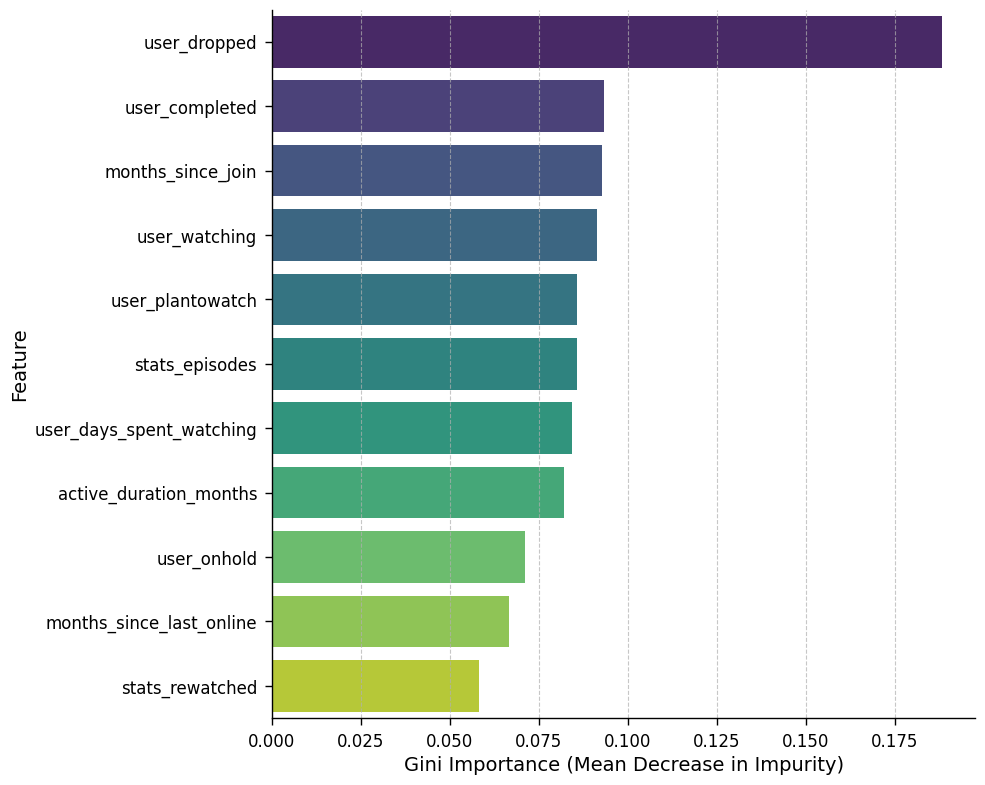

In [15]:
#@title output feature importance from random forest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Regenerate classified_users_df (Clustering Logic)
print("Regenerating user personas via clustering...")
cluster_df = final_user_stats[['username', 'personal_variance', 'avg_score_diff']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df[['personal_variance', 'avg_score_diff']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_df['cluster_num'] = kmeans.fit_predict(scaled_features)

# Map clusters to personas
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=['var', 'diff'])
centroids_sorted = centroids_df.sort_values(by='diff')
label_mapping = {
    centroids_sorted.index[0]: 'Critical',
    centroids_sorted.index[1]: 'Average',
    centroids_sorted.index[2]: 'Generous'
}
cluster_df['user_persona'] = cluster_df['cluster_num'].map(label_mapping)

# Merge with demographic data
users_full = pd.read_csv(base_path + 'users_cleaned.csv')
classified_users_df = users_full.merge(cluster_df[['username', 'user_persona']], on='username', how='inner')

# 2. Feature Engineering for Random Forest
print("Engineering features...")
target_date = pd.to_datetime('2026-01-01')
list_df = classified_users_df.drop(columns=['username', 'user_id', 'access_rank', 'stats_mean_score', 'location', 'gender'], errors='ignore')

date_cols = ['birth_date', 'join_date', 'last_online']
for col in date_cols:
    list_df[col] = pd.to_datetime(list_df[col], errors='coerce')

list_df['active_duration_months'] = (list_df['last_online'].dt.year - list_df['join_date'].dt.year) * 12 + (list_df['last_online'].dt.month - list_df['join_date'].dt.month)
list_df['months_since_join'] = (target_date.year - list_df['join_date'].dt.year) * 12 + (target_date.month - list_df['join_date'].dt.month)
list_df['months_since_last_online'] = (target_date.year - list_df['last_online'].dt.year) * 12 + (target_date.month - list_df['last_online'].dt.month)

list_df = list_df.drop(columns=date_cols).fillna(list_df.median(numeric_only=True))

# 3. Fit Model and Extract Importances
print("Fitting Random Forest and extracting feature importance...")
X = list_df.drop(columns=['user_persona'])
y = list_df['user_persona']

numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
preprocessor = ColumnTransformer(transformers=[('num', 'passthrough', numeric_cols)])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=12, class_weight='balanced', n_estimators=200, random_state=42))
])

rf_pipeline.fit(X, y)
importances = rf_pipeline.named_steps['classifier'].feature_importances_
# SORTED IN DESCENDING ORDER
feature_importance_df = pd.DataFrame({'Feature': numeric_cols, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 4. Plot Results with distinguishable colors
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df,
    y='Feature',
    x='Importance',
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.xlabel('Gini Importance (Mean Decrease in Impurity)', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Remove borders
sns.despine()

plt.tight_layout()
# Save the figure
plt.savefig('feature_importance.png', dpi=300)
plt.show()